# Optimizing Image Classification on Imagenette with fastai: From Baseline to SOTA Techniques
## Project Objective

This notebook demonstrates how to systematically improve image classification performance using practical deep learning techniques. Using the lightweight Imagenette dataset and `fastai`, we compare baseline models (xresnet50/34, resnet18) under various optimization strategies such as:

- Normalization
- Progressive Resizing
- Test-Time Augmentation (TTA)
- Mixup Regularization
- Label Smoothing

The goal is to build an effective experimentation pipeline and extract best practices for image classification under constrained resources (e.g., macOS MPS backend).

**Why Imagenette?**  
Imagenette is a lightweight version of ImageNet (10 classes), suitable for prototyping and benchmarking under limited compute environments.

> 💡 This notebook also documents optimizations adapted for Apple's **MPS backend** on macOS M3 MAX, showcasing how to maximize training efficiency even without NVIDIA GPUs.

In [1]:
from fastai.vision.all import *

In [2]:
path = untar_data(URLs.IMAGENETTE)

## Create a DLS and select a baseline model
### 📌 Baseline Model Selection: XResNet vs ResNet18 (MPS-Compatible)

In the original *fastbook* tutorial for the Imagenette dataset, the authors adopted **XResNet** as the baseline model due to its improved architectural refinements over the standard ResNet, such as a better input stem and normalized activation layers. It consistently demonstrates strong performance in image classification tasks and is the default backbone in many fastai examples.

However, this notebook is executed on a **Mac system using the Metal Performance Shaders (MPS) backend**, which currently has limited compatibility with certain layers and operations used in `XResNet`.

Therefore, I substituted `xresnet50` with the more hardware-compatible **`resnet18`**, a lightweight yet effective architecture available through `torchvision.models`. This change ensures smooth model training and inference while still preserving baseline performance for experimentation with training tricks and optimization strategies.

> 🧠 This also reflects a realistic constraint-driven engineering decision: choosing an appropriate model based on available hardware while maintaining a fair baseline.

## 💡 Note on Dual Model Setup for Experimental Consistency

To validate the effectiveness of each optimization technique (e.g., normalization, progressive resizing, mixup, TTA), **two model setups** were used:

- **XResNet50/34 with custom normalization and `Learner`**:  
  This configuration was chosen to mirror the baseline used in *fastbook*. However, due to performance limitations on the MPS backend (macOS), this setup was extremely slow for experimentation.

- **ResNet18 with built-in normalization using `vision_learner`**:  
  To enable faster iteration while maintaining practical relevance, `resnet18` was selected as an alternative. The `vision_learner` function automatically applies ImageNet normalization and integrates well with fastai's callbacks and scheduling.

> Throughout the notebook, both models are used to cross-validate the impact of each training trick. Where applicable, results from both are compared for clarity.

### xresnet50 as baseline - Runs slow on mps

In [20]:
dblock = DataBlock(blocks=(ImageBlock(), CategoryBlock),
                  get_items=get_image_files,
                  get_y=parent_label,
                  item_tfms=Resize(460),
                  batch_tfms=RandomResizedCrop(260, min_scale=0.75))

In [21]:
dls = dblock.dataloaders(path, bs=24)

In [22]:
model = xresnet50(n_out=dls.c) 
learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
learn.fit_one_cycle(5, 3e-3) #very slow on macOS

epoch,train_loss,valid_loss,accuracy,time
0,1.648788,2.303311,0.285661,08:36
1,1.223694,1.552749,0.507842,08:27
2,0.980092,0.964101,0.712845,08:28
3,0.761844,0.700170,0.792009,08:29
4,0.591804,0.610395,0.822255,08:27


### resnet18 as baseline - Runs fast on mps

In order to test the optimization tricks, I decide to make some changes to run faster:
- item_tfms to smaller size (460 -> 128)
- batch_tfms to smaller size (260 -> 98) 
- model changes to resnet18 and use the `vision_learner` (includes Normalization already)

In [3]:
dblock = DataBlock(blocks=(ImageBlock(), CategoryBlock),
                  get_items=get_image_files,
                  get_y=parent_label,
                  item_tfms=Resize(128),
                  batch_tfms=RandomResizedCrop(98, min_scale=0.75))

dls = dblock.dataloaders(path, bs=32)

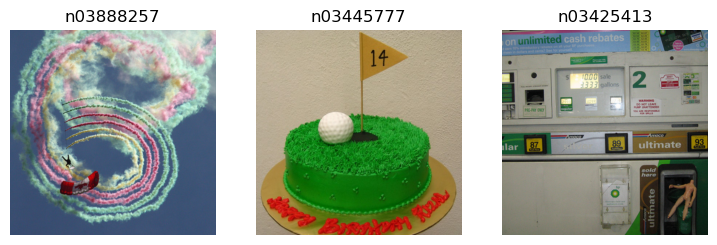

In [11]:
dls.show_batch(max_n=3)

In [4]:
model = resnet18(num_classes=dls.c)
learn = vision_learner(dls, resnet18, metrics=accuracy)

SuggestedLRs(valley=0.001737800776027143)

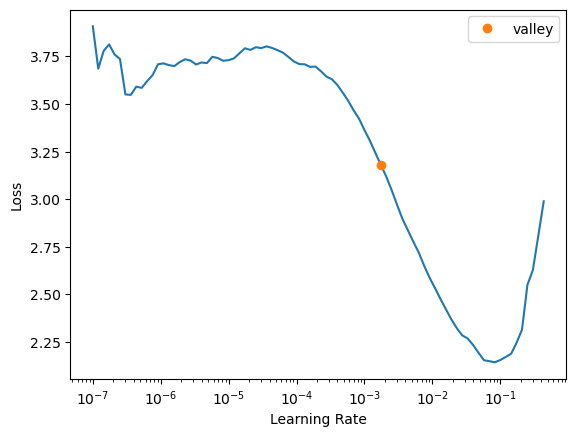

In [5]:
learn.lr_find()

In [6]:
learn.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.495304,0.324447,0.907767,00:46
1,0.443975,0.289220,0.905527,00:46
2,0.354204,0.247439,0.921210,00:46
3,0.253806,0.233607,0.919343,00:47


## Normalization

Normalization is a standard preprocessing step that scales image pixel values to have **zero mean** and **unit variance**. This improves training speed, numerical stability, and convergence—especially when using pretrained models.

- Since **Imagenette** is a subset of **ImageNet**, we apply `Normalize.from_stats(*imagenet_stats)` to ensure compatibility with models pretrained on ImageNet.
- `imagenet_stats` is a tuple of `(mean, std)` derived from the full ImageNet dataset:  
  `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`
- When using `vision_learner`, normalization is automatically included.
- If building a custom `DataBlock`, normalization should be explicitly added in default `Learner`.
- This operation is applied per batch and has negligible computational cost.

📌 **For custom datasets**:  
You should compute dataset-specific statistics for better normalization:

```python
mean, std = dls.train.x.mean(dim=[0,2,3]), dls.train.x.std(dim=[0,2,3])
```

In [5]:
x,y = dls.one_batch()
x.mean(dim=[0,2,3]), x.std(dim=[0,2,3]) #except the channel axis 1

(TensorImage([0.4740, 0.4749, 0.4399], device='mps:0'),
 TensorImage([0.2782, 0.2758, 0.3110], device='mps:0'))

### Custom normalization in `get_dls` 
for default `Learner` here:
```python
model = xresnet50(n_out=dls.c) 
learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
learn.fit_one_cycle(5, 3e-3)
```

In [6]:
def get_dls(bs, size):
    dblock = DataBlock(blocks=(ImageBlock(), CategoryBlock),
                  get_items=get_image_files,
                  get_y=parent_label,
                  item_tfms=Resize(460),
                  batch_tfms=[RandomResizedCrop(size, min_scale=0.75),
                             Normalize.from_stats(*imagenet_stats)])
    return dblock.dataloaders(path, bs=bs)

In [7]:
dls = get_dls(64, 224)
x,y = dls.one_batch()
x.mean(dim=[0,2,3]), x.std(dim=[0,2,3])

(TensorImage([-0.1059, -0.0031,  0.1427], device='mps:0'),
 TensorImage([1.2235, 1.2143, 1.3189], device='mps:0'))

## Progressive Resizing

**Definition**: A training strategy that starts with smaller image resolutions and gradually increases to larger ones throughout training.

- **Early epochs** use small images to accelerate training and help the model learn general features efficiently.
- **Later epochs** switch to high-resolution images to allow the model to refine details, improving final accuracy.

>This technique balances training speed and performance, and is especially effective when compute resources are limited.

### xresnet34 compare
use custom normalization `get_dls` with default `Learner`
- 1st training: batch 64,size 128, lr 3e-3
- 2nd fine_tune: batch 32, size 224, lr 1e-3
- acc: >0.85 (baseline xresnet50 acc: 0.822)

In [44]:
dls = get_dls(64,128) 
learn = Learner(dls, xresnet34(n_out=dls.c), loss_func=CrossEntropyLossFlat(), metrics=accuracy) #resnet50 too slow in mps
learn.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.586073,1.775445,0.415982,05:12
1,1.202580,1.480215,0.586632,05:44
2,0.902410,0.794755,0.744959,05:13
3,0.689305,0.650899,0.804705,05:25


In [45]:
learn.dls = get_dls(32, 224) 
learn.fine_tune(5, 1e-3) 

epoch,train_loss,valid_loss,accuracy,time
0,0.798924,0.751305,0.773712,04:58


epoch,train_loss,valid_loss,accuracy,time
0,0.690535,0.712559,0.775952,05:07
1,0.683097,0.699285,0.788648,04:57
2,0.597943,0.609970,0.812173,04:47
3,0.499342,0.495658,0.847274,04:42
4,0.448878,0.467433,0.855489,04:43


### resnet18 compare
automatic normalization with `vision_learner`
- 1st training: batch 48, size 48, lr 3e-3
- 2nd fine_tune: batch 32, size 98, lr 1e-3
- acc: >0.95 (baseline 0.92)

In [8]:
#re-define get_dls() function:
def get_dls(bs, size):
    dblock = DataBlock(blocks=(ImageBlock(),CategoryBlock()),
                      get_items=get_image_files,
                      get_y=parent_label,
                      item_tfms=Resize(128),
                      batch_tfms=RandomResizedCrop(size, min_scale=0.75))
    return dblock.dataloaders(path, bs=bs)

In [9]:
#1st training with smaller size 
dls = get_dls(48, 48)
learner = vision_learner(dls, resnet18, metrics=accuracy)
learner.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.397299,0.291441,0.917102,00:45
1,0.356374,0.263499,0.914862,00:43
2,0.280798,0.240041,0.925691,00:44
3,0.213126,0.229397,0.926811,00:44


In [12]:
#2nd fine_tune
learner.dls = get_dls(32,98)
learner.fine_tune(3, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.285308,0.138546,0.955937,00:46


epoch,train_loss,valid_loss,accuracy,time
0,0.257064,0.142240,0.955564,00:52
1,0.234063,0.131057,0.957057,00:52
2,0.116793,0.119836,0.959298,00:52


## Test Time Augmentation (TTA)

**Definition**: During inference, generate multiple augmented versions of an input image (e.g., flips, crops), perform predictions on each, and aggregate the results (e.g., via mean or max) to produce a more robust final prediction.

- **Computational Cost**: TTA significantly increases inference time due to multiple forward passes per image. It's important to balance the accuracy gain against the added latency.
- **Use Cases**: Commonly applied in image classification tasks to improve model robustness and accuracy. TTA is widely used in Kaggle competitions and evaluation pipelines for final validation.
> ✅ Supported in Fastai via `learn.tta()`, making it easy to apply at inference time.

### xresnet34 compare
- baseline xresnet50 acc: 0.82
- progressive resizing acc:0.8554
- tta acc:0.8558 

In [ ]:
preds, targets = learn.tta()

In [47]:
accuracy(preds, targets).item() 

0.855862557888031

### resnet18 compare
- baseline acc 0.92
- progressive resizing acc: 0.955
- tta: 0.968

In [13]:
pred_mps, targ_mps = learner.tta()
accuracy(pred_mps, targ_mps).item()

0.968259871006012

## MixUp

**MixUp** is a regularization technique that creates new training samples by **linearly interpolating** between two images and their corresponding labels. It is especially effective in **multi-class classification tasks**, helping to reduce overfitting and improve generalization.

Given two random samples (x1, y1) and (x2, y2), and λ is a random value sampled from a Beta distribution, where λ ∈ [0, 1]:

`x = λ * x1 + (1 - λ) * x2 , y = λ * y1 + (1 - λ) * y2`

-  How to Use in fastai
MixUp is implemented as a **callback** in fastai:

```python
learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy, cbs=MixUp())
```
- **Practical Notes**
    - MixUp is most effective after the model has already learned basic features, so it’s typically used in longer training cycles (e.g., >80 epochs).
    - The augmented labels are soft labels (probabilistic combinations), which encourages the model to be less confident on interpolated samples.

- **Beyond Vision: Activation MixUp**

    - MixUp isn’t limited to raw inputs—Activation MixUp applies interpolation to intermediate layer activations (e.g., (a_1, a_2)) instead of input images, allowing the technique to extend to NLP or tabular data.

    - While softmax/sigmoid outputs never reach exact 0s or 1s, Activation MixUp can push predictions closer to binary extremes over time with sufficient training.
 

### xresnet34 with Mixup
Applying MixUp to the `xresnet34` Learner did not improve performance—in fact, it slightly degraded the results. This is likely due to an insufficient number of training epochs, as MixUp is known to be more effective in longer training schedules.

In [48]:
learn = Learner(dls, xresnet34(n_out=dls.c), loss_func=CrossEntropyLossFlat(), metrics=accuracy, cbs=MixUp())
learn.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.870821,1.526629,0.493279,05:30
1,1.591731,1.533515,0.525392,06:05
2,1.385304,1.014480,0.684839,05:36
3,1.228271,0.785033,0.772218,05:32


## Label Smoothing

MixUp can introduce label uncertainty by blending class labels, which may hinder model convergence if not handled properly. To mitigate this, Label Smoothing can be applied—this technique prevents the model from becoming overconfident by softening the target labels.

For example, a one-hot encoded target like:
y = [0, 0, 1, 0]

would be transformed into a smoothed version:
y_smooth = [0.1, 0.1, 0.8, 0.1]

- In Fastai, Label Smoothing can be implemented via the custom loss function:
```python
learn = Learner(dls, xresnet34(n_out=dls.c), loss_func=LabelSmoothingCrossEntropy(), metrics=accuracy)
learn.fit_one_cycle(4, 3e-3)
```
This loss function is particularly useful when used in conjunction with techniques like MixUp or when training on noisy labels.

### resnet18 with Mixup+LabelSmoothing
|Condition|accuracy|improve|
|---------|--------|-------|
| baseline with no tricks| 0.92||
|only `mixup(0.3)`| 0.942 |little improvement|
|`mixup(0.3)` + `labelsmoothing(0.8)`| 0.929  |not much improve|
|`mixup(0.3)` + `labelsmoothing(0.1)`| 0.933  |not much improve|
|only `labelsmoothing(0.1)`| 0.932 | not much improve|

In [19]:
#just add mixup()
from fastai.callback.mixup import *
dls = get_dls(48, 98)
learner = vision_learner(dls, resnet18, metrics=accuracy, cbs=MixUp(0.3))
learner.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.148357,0.251010,0.926811,00:45
1,0.943257,0.258138,0.929425,00:45
2,0.863209,0.258656,0.936520,00:44
3,0.814270,0.248662,0.942121,00:44


In [20]:
LabelSmoothingCrossEntropy??

Init signature:
LabelSmoothingCrossEntropy(
    eps: 'float' = 0.1,
    weight: 'Tensor' = None,
    reduction: 'str' = 'mean',
)
Docstring:      Same as `nn.Module`, but no need for subclasses to call `super().__init__`
Source:        
class LabelSmoothingCrossEntropy(Module):
    y_int = True # y interpolation
    def __init__(self, 
        eps:float=0.1, # The weight for the interpolation formula
        weight:Tensor=None, # Manual rescaling weight given to each class passed to `F.nll_loss`
        reduction:str='mean' # PyTorch reduction to apply to the output
    ): 
        store_attr()

    def forward(self, output:Tensor, target:Tensor) -> Tensor:
        "Apply `F.log_softmax` on output then blend the loss/num_classes(`c`) with the `F.nll_loss`"
        c = output.size()[1]
        log_preds = F.log_softmax(output, dim=1)
        if self.reduction=='sum': loss = -log_preds.sum()
        else:
            loss = -log_preds.sum(dim=1) #We divide by that size at the return line

In [21]:
#add mixup + labelsmoothing (eps 0.8 - interpolation weight)
learner.loss_func = LabelSmoothingCrossEntropy(eps=0.8)
learner.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,2.274459,2.204993,0.925691,00:44
1,2.237962,2.207193,0.918969,00:44
2,2.230731,2.199317,0.926811,00:44
3,2.226471,2.196797,0.929798,00:44


In [22]:
dls = get_dls(32, 98)
learner.loss_func = LabelSmoothingCrossEntropy(eps=0.1)
learner.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.201308,0.750140,0.917102,00:44
1,1.161672,0.743647,0.918223,00:43
2,1.140195,0.714435,0.930919,00:44
3,1.111564,0.704118,0.933159,00:44


In [23]:
#just add labelsmoothing
learner = vision_learner(dls, resnet18, metrics=accuracy, 
                         loss_func=LabelSmoothingCrossEntropy(eps=0.1))
learner.fit_one_cycle(4, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.001590,0.840392,0.902913,00:45
1,0.893168,0.763254,0.911128,00:46
2,0.785958,0.722831,0.926811,00:47
3,0.740733,0.711386,0.932039,00:47


##  Performance Comparison Summary

| Technique              | Accuracy (xresnet50/xresnet34) | Accuracy (resnet18) | Training Time (per epoch) | Notes                                      |
|------------------------|----------------------|----------------------|----------------------------|--------------------------------------------|
| Baseline               | 0.82 (xresent50) | 0.92 | ~8 min  / ~45 sec     | xresnet slow on MPS, resnet18 is MPS-friendly |
| Progressive Resizing   | 0.8554(xresnet34)| 0.955 | ~5 min  / ~45 sec  | Better generalization, faster convergence  |
| TTA                    | 0.8558 (xresnet34)| 0.968 ⭐️| Inference only             | Improves test-time accuracy                |
| Mixup                  | 0.77(worse)(xresnet34)| 0.942 | Slightly longer            | Requires longer training for effect        |
| Label Smoothing        | — | 0.933 | ~same  | Helps reduce overconfident predictions     |


## Conclusion: Practical Insights from Optimization Techniques

This notebook systematically evaluates a range of widely adopted deep learning optimization techniques for image classification using the *Imagenette* dataset. By comparing two architectures—`xresnet34` (used as the baseline in fastbook) and `resnet18` (MPS-friendly)—we uncover the practical strengths and trade-offs of various training strategies in resource-constrained environments.

Key observations:

- **Hardware Compatibility Matters**: `resnet18` showed significantly better speed and compatibility on Apple’s MPS backend, making it a better baseline for fast experimentation and iteration on Mac.

- **Progressive Resizing** consistently improved generalization and final accuracy across both architectures, affirming its value as a simple yet powerful strategy for accelerating training while maintaining performance.

- **Test-Time Augmentation (TTA)** yielded the highest accuracy (96.8%) on `resnet18`, demonstrating its effectiveness for improving model robustness during inference, especially in evaluation-heavy settings like competitions or deployments.

- **Mixup** showed reduced performance on `xresnet34` due to insufficient training epochs, underscoring the importance of properly tuning epochs and hyperparameters for augmentation-heavy training.

- **Label Smoothing** helped regularize predictions and avoid overconfidence in the final layers, offering a low-cost enhancement with measurable gain.

### Engineering Impact

This notebook not only benchmarks multiple training strategies on a compact dataset, but also illustrates how to adapt model selection and training to platform constraints. The results provide a practical guide for deploying efficient, high-performing image classification models on resource-limited hardware.

> This workflow serves as a strong template for real-world model tuning on edge or resource-constrained devices.